<a href="https://colab.research.google.com/github/Manavee-Singh-811/Quant-Journey-2026/blob/main/notebooks/Day_03_Stationarity_ADF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller



In [2]:
ticker = "^NSEI"
df = yf.download(ticker, period="1y")

/tmp/ipykernel_2583/3316094204.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


In [3]:
def run_adf_test(series, title):
  print(f" --- ADF Test for {title} ---")
  #Drop NaN because ADF cant handle missing values
  result = adfuller(series.dropna())
  print(f'ADF Statistic: {result[0]: .4f}')
  print(f'p-value: {result[1]: .4f}')

  #Define threshold
  if result[1] <= 0.05:
    print("Result: Stationary (Mean is stable)")
  else:
    print("Result: Non-Stationary (Contains drift)" )
  print("-"*30)


In [5]:
#Compare Raw Price vs. Daily Returns
run_adf_test(df['Close'], "Raw Close Price")

 --- ADF Test for Raw Close Price ---
ADF Statistic: -2.6949
p-value:  0.0749
Result: Non-Stationary (Contains drift)
------------------------------


In [6]:
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
run_adf_test(df['Log_Returns'], "Log Returns")

 --- ADF Test for Log Returns ---
ADF Statistic: -15.6048
p-value:  0.0000
Result: Stationary (Mean is stable)
------------------------------


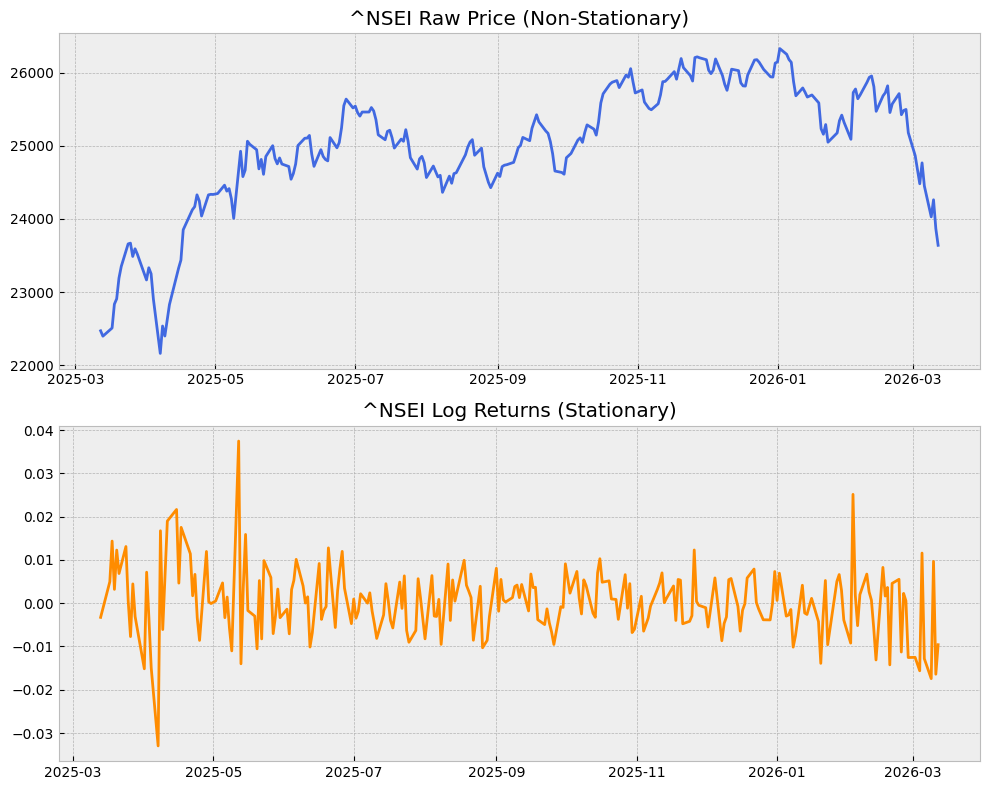

In [7]:
plt.style.use('bmh')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(df['Close'], color='royalblue')
ax1.set_title(f"{ticker} Raw Price (Non-Stationary)")

ax2.plot(df['Log_Returns'], color='darkorange')
ax2.set_title(f"{ticker} Log Returns (Stationary)")

plt.tight_layout()
plt.show()

# Key Takeaway

The p-value Rule:
In Quant Finance, a p-value <= 0.05 is the "Gold Standard".
It means there is less than a 5% chance the data is just drifting randomly.

Why Raw Price Fails: The "Raw Close Price" almost always fails (Non-Stationary) because the price "travels".
Log Returns: By calculating the change between days, we "stabilize" the data, making it usable for the ML models